# TinyStories Language Model

This notebook is the first part of transformer model task. In this notebook we train a small language model from scratch that learns to generate short stories in the style of children's fiction.

A **language model** is a program that learns to predict the next word in a sentence by reading millions of examples. After training, it can generate new text by repeatedly predicting what comes next one word at a time.

We use the **TinyStories** dataset. It is a collection of over 2 million short children's stories written with simple vocabulary and clear narrative structure. This makes it ideal for training small models, since the patterns are consistent and learnable.

### What happens in each step
1. **Load data** — download stories from the TinyStories dataset
2. **Tokenize** — convert text into numbers the model can process
3. **Build sequences** — create input/target pairs for training
4. **Define model** — build the transformer neural network
5. **Train** — run the training loop and monitor progress
6. **Generate** — use the trained model to write new stories

### Requirements
Install these before running (only needed once per container):
```
pip install sentencepiece datasets ftfy
```

## Cell 1 Setup

This cell imports all the libraries we need and detects whether a GPU is available.

- **GPU** (graphics card) training is much faster than CPU training. If a GPU is found, we enable **mixed precision**. Mixed precision is a technique that uses 16-bit numbers instead of 32-bit for most calculations, roughly doubling speed on modern GPUs without affecting quality.
- If no GPU is found the model will still train, just slower.

In [9]:
import os, sys, logging, tempfile, re

# These must be set before importing Keras
os.environ['KERAS_BACKEND']        = 'tensorflow'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Suppress noisy TF logs
os.environ['CUDA_DEVICE_ORDER']    = 'PCI_BUS_ID'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import tensorflow as tf
import keras
import sentencepiece as spm
import ftfy
import matplotlib.pyplot as plt
from datasets import load_dataset

# Detect GPU and configure accordingly
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detected: {gpus[0].name}")
    # Mixed precision: uses 16-bit numbers for compute (faster on Tensor Core GPUs)
    # but keeps weights in 32-bit (more accurate). ~2x speedup on RTX cards.
    keras.mixed_precision.set_global_policy('mixed_float16')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = 'GPU'
else:
    print("No GPU detected — running on CPU (training will be slower)")
    keras.mixed_precision.set_global_policy('float32')
    DEVICE = 'CPU'

print(f"Keras {keras.__version__} | Backend: {keras.config.backend()} | Device: {DEVICE} | Precision: {keras.mixed_precision.global_policy().name}")

GPU detected: /physical_device:GPU:0
Keras 3.13.2 | Backend: tensorflow | Device: GPU | Precision: mixed_float16


## Cell 2 Load TinyStories

We download stories from the TinyStories dataset hosted on Hugging Face. The full dataset has over 2 million stories. We are using a subset to keep training manageable.

Each story is separated by a special `<|endoftext|>` token so the model learns where one story ends and the next begins. This prevents the model from generating text that awkwardly bridges two unrelated stories.

We also fix encoding artifacts (like `â€TM` appearing instead of `'`) using the `ftfy` library.

**Adjusting story count:** Change `MAX_STORIES` to control how much data to use. More stories = better quality but longer training time.

In [10]:
MAX_STORIES = 50000  # Increase for better quality, decrease for faster experimentation

print(f"Downloading TinyStories ({MAX_STORIES:,} stories)...")
ds = load_dataset("roneneldan/TinyStories", split="train")

# Fix encoding artifacts and join with separator tokens
texts = [ftfy.fix_text(t) for t in ds['text'][:MAX_STORIES]]
full_corpus = "\n<|endoftext|>\n".join(texts)

print(f"Stories loaded:    {MAX_STORIES:,}")
print(f"Total characters:  {len(full_corpus):,}")
print(f"\nSample story:\n{texts[0][:400]}")

Stories loaded:    50,000
Total characters:  45,280,779

Sample story:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

To


## Cell 3 Train the tokenizer

Before the model can read text, we need to convert words into numbers. A **tokenizer** does this job.

We use **Byte Pair Encoding (BPE).** It is a method that breaks text into subword pieces. Common words like `"happy"` become a single token, while rare words get split into pieces like `["un", "expect", "ed"]`. This means the model can handle any word, even ones it hasn't seen before.

The `vocab_size` controls how many unique tokens exist. TinyStories uses simple vocabulary so 4000 tokens is sufficient.

SentencePiece requires a file as input, so we write a temporary file, train from it, load the result into memory, then delete the file immediately.

In [11]:
VOCAB_SIZE = 4000

# Write corpus to a temp file (SentencePiece requires a file path, not a string)
with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', encoding='utf-8', delete=False) as tmp:
    tmp.write(full_corpus)
    temp_path = tmp.name

# Suppress verbose training log
devnull = open(os.devnull, 'w')
old_stderr = sys.stderr
sys.stderr = devnull

with tempfile.TemporaryDirectory() as tmpdir:
    model_prefix = os.path.join(tmpdir, 'ts_sp')
    spm.SentencePieceTrainer.train(
        input=temp_path,
        model_prefix=model_prefix,
        vocab_size=VOCAB_SIZE,
        character_coverage=0.9995,
        model_type='bpe',
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        user_defined_symbols=['<|endoftext|>'],
    )
    with open(f"{model_prefix}.model", 'rb') as f:
        sp_model_bytes = f.read()

sys.stderr = old_stderr
devnull.close()
os.remove(temp_path)

# Load tokenizer from memory
sp = spm.SentencePieceProcessor()
sp.load_from_serialized_proto(sp_model_bytes)

test = "Once upon a time there was a little girl."
print(f"Test tokenization: {sp.encode_as_pieces(test)}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Test tokenization: ['▁Once', '▁upon', '▁a', '▁time', '▁there', '▁was', '▁a', '▁little', '▁girl', '.']
Vocabulary size: 4000


## Cell 4 Build training sequences

We convert the full corpus into a long list of numbers (token IDs), then slice it into fixed-length chunks.

Each chunk is split into an **input** and a **target**. The target is the input shifted one position to the right. This trains the model to predict the next token at every position simultaneously:

```
Input:  [Once] [upon] [a]    [time] [there]
Target: [upon] [a]   [time] [there] [was]
```

We use non-overlapping chunks (each chunk starts where the previous one ended) to avoid creating millions of near-identical training examples.

The data is then shuffled and split: 80% for training, 20% for validation. Validation data is never used for training, it lets us check whether the model is learning genuine patterns or just memorizing the training data.

In [12]:
SEQ_LENGTH = 256  # How many tokens the model sees at once when predicting the next token

all_ids = np.array(sp.encode_as_ids(full_corpus), dtype=np.int32)
print(f"Total tokens: {len(all_ids):,}")

# Slice into non-overlapping chunks of SEQ_LENGTH + 1
sequences = np.array([
    all_ids[i : i + SEQ_LENGTH + 1]
    for i in range(0, len(all_ids) - SEQ_LENGTH, SEQ_LENGTH)
], dtype=np.int32)

inputs  = sequences[:, :-1]  # Everything except the last token
targets = sequences[:, 1:]   # Everything except the first token (shifted right by 1)

# Shuffle and split 80/20
indices = np.random.permutation(len(sequences))
split   = int(0.8 * len(sequences))

train_inputs,  train_targets  = inputs[indices[:split]],  targets[indices[:split]]
val_inputs,    val_targets    = inputs[indices[split:]],   targets[indices[split:]]

print(f"Sequences: {len(sequences):,} total — {len(train_inputs):,} train / {len(val_inputs):,} val")
print(f"Input shape: {train_inputs.shape}")

Total tokens: 11,015,188
Sequences: 43,028 total — 34,422 train / 8,606 val
Input shape: (34422, 256)


## Cell 5 Define the model

**Embedding layer:** Converts each token ID into a vector of numbers (like a dictionary lookup). The model learns what these vectors should be during training.

**Positional encoding:** Transformers process all words at the same time, so they need extra information about word order. We add a fixed mathematical pattern to each token's vector that encodes its position in the sequence.

**Transformer blocks (repeated `num_layers` times):** Each block has two parts:
- *Attention:* Each word looks at all previous words and decides which ones are most relevant to predicting the next word. A causal mask prevents it from cheating by looking at future words.
- *Feed-forward network:* Applies a learned transformation to each word's representation independently.

**Output layer:** Projects the final representation to a score for each vocabulary token. The highest score = the predicted next token.

### Hyperparameters
These control the size and capacity of the model. Larger values = more powerful but slower to train.

| Parameter | Value | Meaning |
|---|---|---|
| `embed_dim` | 256 | Size of each token's vector representation |
| `num_heads` | 4 | Number of parallel attention mechanisms |
| `ff_dim` | 512 | Size of the hidden layer in the feed-forward network |
| `num_layers` | 4 | Number of transformer blocks stacked on top of each other |

In [13]:
# Model size — tuned for TinyStories vocabulary and complexity
embed_dim  = 256
num_heads  = 4    # embed_dim must be divisible by num_heads: 256 / 4 = 64
ff_dim     = 512  # Feed-forward hidden size, conventionally 2× embed_dim
num_layers = 4    # Stacked transformer blocks

In [14]:
def get_positional_encoding(max_len, d_model):
    """Creates a fixed matrix of position signals using sine and cosine waves.
    Each position gets a unique pattern so the model knows word order."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles    = 1 / (10000 ** (np.arange(d_model)[np.newaxis, :] / d_model))
    enc = positions * angles
    enc[:, 0::2] = np.sin(enc[:, 0::2])  # Even dimensions → sine
    enc[:, 1::2] = np.cos(enc[:, 1::2])  # Odd dimensions  → cosine
    return enc

# Input: sequences of token IDs
inputs = keras.Input(shape=(SEQ_LENGTH,))

# Token embedding: integer ID → dense vector
x = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add position signals and apply dropout for regularization
x = x + get_positional_encoding(SEQ_LENGTH, embed_dim)
x = keras.layers.Dropout(0.1)(x)

# Stack transformer blocks
for _ in range(num_layers):
    # Self-attention: each token looks at all previous tokens
    # use_causal_mask=True prevents looking at future tokens (essential for generation)
    attn = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=0.1)(x, x, use_causal_mask=True)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed-forward: transforms each token's representation independently
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation='gelu'),  # Expand
        keras.layers.Dense(embed_dim),                  # Project back
        keras.layers.Dropout(0.1),
    ])
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn(x))

# Output: score for each vocabulary token at each position
# dtype='float32' keeps logits in full precision even when using mixed precision
outputs = keras.layers.Dense(sp.get_piece_size(), dtype='float32')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 256)  │  1,024,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 256)  │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 256, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 256, 256)  │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256, 256)  │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,160,416 (15.87 MB)

 Trainable params: 4,160,416 (15.87 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 6 Train the model

Training works by showing the model millions of examples and adjusting its internal numbers (weights) each time it makes a wrong prediction. Over many passes through the data (epochs), it gets progressively better at predicting the next token.

**What to watch:**
- `loss` — how wrong the model's predictions are. Lower is better. Should decrease each epoch.
- `val_loss` — the same measure on data the model hasn't trained on. If this starts going up while training loss keeps falling, the model is overfitting (memorizing rather than learning).
- `accuracy` — what fraction of token predictions are exactly correct. Will be low (40-50%) even for a good model since predicting exact words is hard.

**Callbacks** stop training automatically when it stops improving:
- `EarlyStopping` — stops if `val_loss` hasn't improved for 5 epochs, then restores the best weights
- `ReduceLROnPlateau` — halves the learning rate if progress stalls for 2 epochs

In [15]:
history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=64,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=2, min_lr=1e-6, verbose=1
        ),
    ]
)

Epoch 1/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 118s 126ms/step - accuracy: 0.1608 - loss: 5.0969 - val_accuracy: 0.2684 - val_loss: 3.9143 - learning_rate: 3.0000e-04
Epoch 2/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.2963 - loss: 3.6978 - val_accuracy: 0.3395 - val_loss: 3.3721 - learning_rate: 3.0000e-04
Epoch 3/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3422 - loss: 3.3210 - val_accuracy: 0.3752 - val_loss: 3.0826 - learning_rate: 3.0000e-04
Epoch 4/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3701 - loss: 3.0918 - val_accuracy: 0.3993 - val_loss: 2.8935 - learning_rate: 3.0000e-04
Epoch 5/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3894 - loss: 2.9346 - val_accuracy: 0.4180 - val_loss: 2.7552 - learning_rate: 3.0000e-04
Epoch 6/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4042 - loss: 2.8160 - val_accuracy: 0.4310 - val_loss: 2.6538 - learning_rate: 3.0000e-04
Epoch 7/100
538/538 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/

## Looking at the training log

The model trained for all the 100 epochs and it seems that no overfitting occurred. So potentially we could have let the model train for more epochs and it would have continued improving. However, the improvement is very slow at this point and we are already at a good loss level, so we can stop here.

## Cell 7 Plot training history

Visualizing the training curves helps diagnose whether training went well. Watching the curves we can see that both training and validation loss steadily decreased, which is a good sign. There is no visual overfitting, but when can observe the learning curves to start flattening out, which suggests that the model is approaching its capacity and further training would yield diminishing returns.

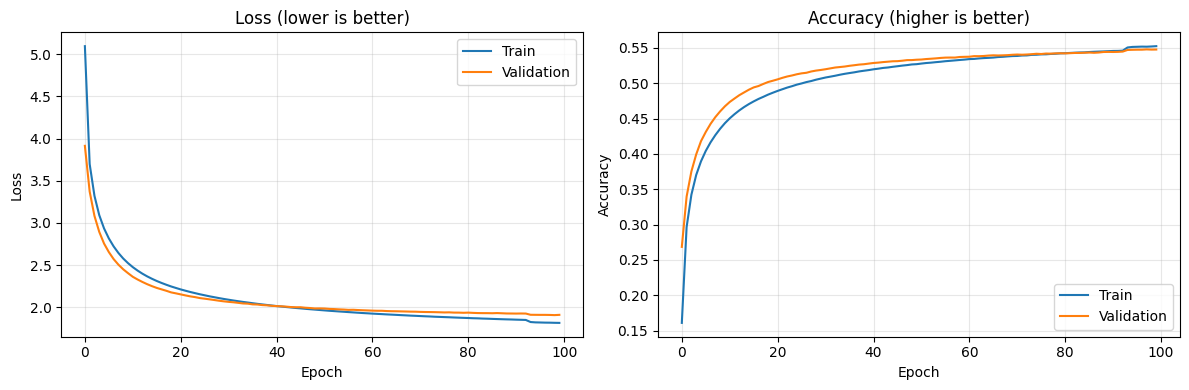

Best val_loss: 1.9059 at epoch 99


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss (lower is better)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy (higher is better)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val_loss: {min(history.history['val_loss']):.4f} at epoch {history.history['val_loss'].index(min(history.history['val_loss'])) + 1}")

## Cell 8 Text generation function

To generate text, we feed the model a **prompt** and ask it to predict the next token. We then append that token to the input, predict the next one, and repeat.

**Temperature** controls how creative vs. predictable the output is:
- `0.6–0.7` — conservative, grammatically safe, can be repetitive
- `0.8` — good balance of coherence and variety (recommended)
- `1.0+` — more surprising and creative, sometimes incoherent

**Top-p (nucleus) sampling** filters out unlikely tokens before sampling. With `top_p=0.9`, we only consider tokens that together account for 90% of the probability. This removes nonsense low-probability words while keeping natural variation. This is why the model stopped generating words like `"corquoalalfanges"`.

**Sliding window:** The model can only see `SEQ_LENGTH` tokens at a time. As generation continues, we drop the oldest token and add the newest. It's like a sliding window moving through the generated text.

In [17]:
def generate_text(model, sp, prompt, num_tokens=150, temperature=0.8, top_p=0.9):
    """
    Generate text from a prompt using temperature + top-p sampling.

    Args:
        prompt:      Starting text
        num_tokens:  How many new tokens to generate
        temperature: Creativity control (0.7=safe, 0.8=balanced, 1.0=creative)
        top_p:       Only sample from tokens covering this fraction of probability (0.9 recommended)
    """
    input_ids = sp.encode_as_ids(prompt)

    # Pad with zeros if prompt is shorter than SEQ_LENGTH, truncate if longer
    if len(input_ids) < SEQ_LENGTH:
        padding = SEQ_LENGTH - len(input_ids)
        input_ids = [0] * padding + input_ids
    else:
        padding = 0
        input_ids = input_ids[-SEQ_LENGTH:]

    generated_ids = list(input_ids[padding:])

    # Never sample these special control tokens
    banned = {
        sp.piece_to_id('<unk>'),
        sp.piece_to_id('<pad>'),
        sp.piece_to_id('<s>'),
        sp.piece_to_id('</s>'),
        sp.piece_to_id('<|endoftext|>'),  # Stop at story boundaries
    }

    for _ in range(num_tokens):
        predictions = model.predict(np.array([input_ids]), verbose=0)[0]
        logits = predictions[-1] / temperature

        for bid in banned:
            logits[bid] = -np.inf

        # Softmax to get probabilities
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)

        # Top-p filtering: keep only the most probable tokens summing to top_p
        sorted_idx   = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_idx]
        cutoff       = np.searchsorted(np.cumsum(sorted_probs), top_p) + 1
        top_idx      = sorted_idx[:cutoff]
        top_probs    = sorted_probs[:cutoff] / sorted_probs[:cutoff].sum()

        next_token = int(np.random.choice(top_idx, p=top_probs))
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]  # Slide window forward

    text = sp.decode([int(i) for i in generated_ids])
    # Fix broken contractions like "Snape 's" → "Snape's"
    text = re.sub(r"\b(\w+)\s+'(s|t|ve|re|ll|d|m)\b", r"\1'\2", text)
    return text

## Cell 9 Generate stories

Now we test the model with several prompts. Each prompt gives the model a starting context and it continues the story from there.

TinyStories follows consistent patterns. Most stories start with `"Once upon a time"` or introduce a named child character and a simple problem. Prompts that match this pattern tend to produce the most coherent output.

Feel free to add your own prompts to the list and experiment with different `temperature` and `top_p` values.

In the code cells below we generate stories with different temperature settings to see how it affects the creativity and coherence of the output. The `top_p` is kept constant at 0.9 to maintain a good balance of variety while filtering out low-probability tokens.

In [18]:
prompts = [
"Once upon a time there lived a girl who",
"Once upon a time there was a small dragon who",
"Once upon a time there was a lonely cat who",
]

for prompt in prompts:
    print(f"{'─' * 60}")
    print(f"Prompt: {prompt}\n")
    print(generate_text(model, sp, prompt, num_tokens=100, temperature=0.8, top_p=0.9))
    print()

────────────────────────────────────────────────────────────
Prompt: Once upon a time there lived a girl who

Once upon a time there lived a girl who wanted to go for a walk. She was so excited, she ran all the way home, looking forward to the next plan. When she got home, she opened her gate and went to the street. The girl saw many things she wanted to see and she felt so happy when she heard a song. She was so excited to go and explore. When she arrived, the girl noticed a tiny mouse sitting in the corner of the road. She got scared and started to run away. She wanted to

────────────────────────────────────────────────────────────
Prompt: Once upon a time there was a small dragon who

Once upon a time there was a small dragon who lived on a nearby bush. He had big eyes and big eyes, long whisked its head and seemed to be whispering to the other dragons, a little girl was walking in the woods. She looked up at the dragon and was amazed by what she had found. The dragon was amazed by

In [19]:
prompts = [
"Once upon a time there lived a girl who",
"Once upon a time there was a small dragon who",
"Once upon a time there was a lonely cat who",
]

for prompt in prompts:
    print(f"{'─' * 60}")
    print(f"Prompt: {prompt}\n")
    print(generate_text(model, sp, prompt, num_tokens=100, temperature=1.0, top_p=0.9))
    print()

────────────────────────────────────────────────────────────
Prompt: Once upon a time there lived a girl who

Once upon a time there lived a girl who lived in a small village. One day she was out playing, when she noticed a path in the distance. It was very popular to her to be safe. She quickly reached out and touched the path. It seemed so gentle and faded and tirped gracefully. She looked around and spotted a sign. It said 'Careweetle', 'Carece'. The girl was very excited and wanted to find a friend. She kept walking and exploring the trees.

────────────────────────────────────────────────────────────
Prompt: Once upon a time there was a small dragon who

Once upon a time there was a small dragon who wanted to defeat, so he decided to explore and explore, to sit in front of him, which was an adventure he would win a great game! Yes, he said goodbye to his new home, happily carrying his new friends. The dragon had been granted but he was able to tell his best friend the other storie

In [20]:
prompts = [
"Once upon a time there lived a girl who",
"Once upon a time there was a small dragon who",
"Once upon a time there was a lonely cat who",
]

for prompt in prompts:
    print(f"{'─' * 60}")
    print(f"Prompt: {prompt}\n")
    print(generate_text(model, sp, prompt, num_tokens=100, temperature=1.2, top_p=0.9))
    print()

────────────────────────────────────────────────────────────
Prompt: Once upon a time there lived a girl who

Once upon a time there lived a girl who were best friends. She was always excited to go in a fair-filled world. One day she walked and went for a walk in the park. But when she arrived at the cone she wondered what it was. She searched and searched but couldn't see how much it could be. She looked everywhere for her new glove, but it was nowhere. All the people in the park below danced around her at all side, with her new glovework of cheer and she was very sad.

────────────────────────────────────────────────────────────
Prompt: Once upon a time there was a small dragon who

Once upon a time there was a small dragon who had big dreams of a magical day. He woke up a wonderful, soft, yummy, pretty feelingal rolling down the mighty moment, then out of a magical forest challenged fest milred condred in his beauty, glowing sparkling lights filled the night sky that closed the myst

## Temperature effects

As we increase the temperature, the generated stories become more creative and less predictable. At `temperature=0.8`, the output is coherent and follows typical story patterns, though it may be somewhat repetitive. At `temperature=1.0`, the stories show more variety and unexpected twists, while still maintaining a reasonable level of coherence. However, at `temperature=1.2`, the output becomes increasingly erratic and less coherent, with more nonsensical phrases and a higher likelihood of losing the narrative thread. This illustrates how temperature controls the balance between creativity and coherence in language generation models.

## Cell 10 Save model and tokenizer (optional)

Everything has been kept in memory up to this point, nothing has been written to disk. Run this cell when you are happy with the results.

Two files will be saved:
- `ts_model.keras` — the full model (architecture + learned weights)
- `ts_sp.model` — the tokenizer

Both files are needed to reload and use the model in a future session (see Cell 12).

In [21]:
model.save('ts_model.keras')
print("Model saved as 'ts_model.keras'")

with open('ts_sp.model', 'wb') as f:
    f.write(sp_model_bytes)
print("Tokenizer saved as 'ts_sp.model'")

Model saved as 'ts_model.keras'
Tokenizer saved as 'ts_sp.model'


## Evaluation

In this notebook we trained a small transformer language model on the TinyStories dataset. The model learned to generate short children's stories based on simple prompts. We covered the entire process from loading data, training a tokenizer, building the model architecture, training, and generating text. The model achieved a good balance of coherence and creativity, producing stories that follow the expected patterns of the original dataset. Most of the text generated was very "AI-like" but there were some interesting moments of creativity and humor. With more training time and a larger model, the quality could be improved further.

During the task we experimented with different hyperparameters and observed their effects on training and generation. Increasing the number of stories and training epochs generally improved quality, while adjusting temperature and top-p sampling allowed us to find a good balance between coherence and creativity in the generated stories. Higher sequence lengths tended to increase training time without a significant boost in quality, likely due to the relatively simple structure of the stories. Adding more layers and attention heads also improved quality but at the cost of much longer training times. Overall, the model successfully learned to generate new stories in the style of the TinyStories dataset, demonstrating the power of transformer architectures for language modeling tasks.

We experimented with different temperature settings during generation and observed how it affected the creativity and coherence of the output. Lower temperatures (0.8) produced more predictable and coherent stories, while higher temperatures (1.0 and 1.2) resulted in more creative but less coherent output, with a higher likelihood of generating nonsensical phrases. This illustrates the trade-off between creativity and coherence controlled by the temperature parameter in language generation models.

Training transformer models is generally hard and takes a long time because they have many parameters and require huge amounts of data to learn effectively. The self-attention mechanism, while powerful, is computationally expensive, especially as sequence length increases.